### Mini Project: COVID-19 Detection from Chest X-rays using CNN
This project builds a Convolutional Neural Network (CNN) model to automatically detect COVID-19 from chest X-ray images. The dataset contains three classes: COVID-19, Normal (no disease), and Viral Pneumonia.

In [1]:
# Imports necessary libraries for data processing, visualization, deep learning (TensorFlow/Keras), and hyperparameter tuning.
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.applications import VGG16, ResNet50
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
import keras_tuner as kt
import kagglehub

c:\Users\singh\OneDrive\Desktop\cnn_mini_project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Data Loading and Exploration

Loaded 251 training images and 66 test images.


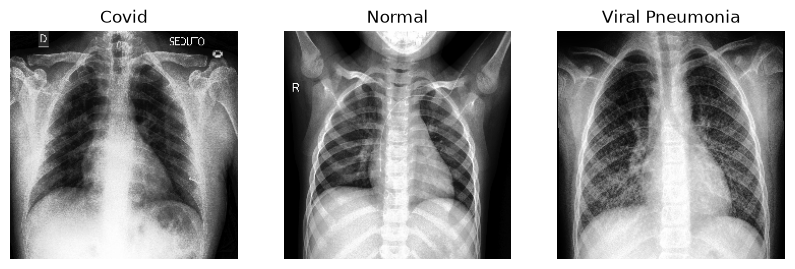

In [2]:
# Loads images from train and test folders, resizes them to 224x224, labels them, and prints dataset sizes.
base_dir = kagglehub.dataset_download('pranavraikokte/covid19-image-dataset') + '/Covid19-dataset'
classes = ['Covid', 'Normal', 'Viral Pneumonia']
img_size = 224

def load_data(folder_name):
    X_data, y_data = [], []
    for category in classes:
        path = os.path.join(base_dir, folder_name, category)
        class_num = classes.index(category)
        for img in os.listdir(path):
            img_array = cv2.imread(os.path.join(path, img))
            if img_array is not None:
                resized_array = cv2.resize(img_array, (img_size, img_size))
                X_data.append(resized_array)
                y_data.append(class_num)
    return np.array(X_data), y_data

X_train_full, y_train_full_list = load_data('train')
X_test, y_test_list = load_data('test')

print(f"Loaded {len(X_train_full)} training images and {len(X_test)} test images.")

# Display a few sample images from each class
plt.figure(figsize=(10, 5))
for i in range(3):
    plt.subplot(1, 3, i+1)
    idx = y_train_full_list.index(i)
    plt.imshow(cv2.cvtColor(X_train_full[idx], cv2.COLOR_BGR2RGB))
    plt.title(classes[i])
    plt.axis('off')
plt.show()

# Convert label lists to numpy arrays for further processing
y_train_full = np.array(y_train_full_list)
y_test = np.array(y_test_list)

### EDA Class Distribution

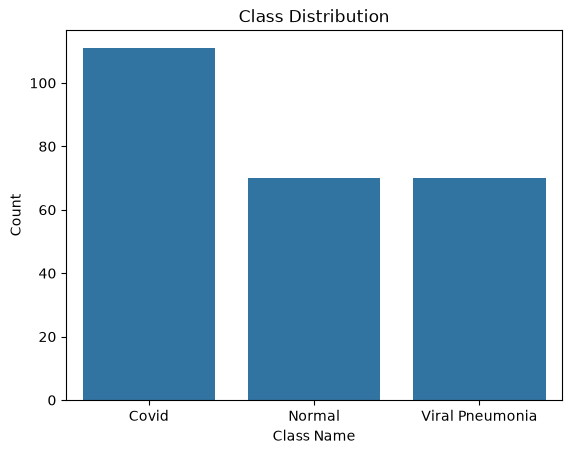

In [3]:
# Visualizes the class distribution using a bar plot to observe patterns in the data.
sns.countplot(x=[classes[label] for label in y_train_full])
plt.title('Class Distribution')
plt.xlabel('Class Name')
plt.ylabel('Count')
plt.show()

### Preprocess and split only validation from train

In [4]:
# Normalizes pixel values, encodes labels, and splits the training data to create a validation set (80-20% split).
X_train_full = X_train_full / 255.0
X_test = X_test / 255.0

y_train_full_encoded = to_categorical(y_train_full, num_classes=3)
y_test = to_categorical(y_test, num_classes=3)

X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full_encoded, test_size=0.2, random_state=42)

### Handle Class Imbalance

In [5]:
# Analyzes class imbalance and sets up techniques like computing class weights and data augmentation using ImageDataGenerator.
y_integers = np.argmax(y_train, axis=1)
class_weights = compute_class_weight('balanced', classes=np.unique(y_integers), y=y_integers)
class_weights_dict = dict(enumerate(class_weights))

datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)
datagen.fit(X_train)

### Model Evaluation Function

In [6]:
# Defines a reusable function to evaluate models, plot train vs val metrics, print ROC-AUC/Test Acc, and display the confusion matrix.
def evaluate_model(model, history, X_test, y_test):

    print(f"Trainable Parameters: {np.sum([tf.keras.backend.count_params(w) for w in model.trainable_weights])}")
    loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
    print(f"Test Accuracy: {accuracy:.4f}\n")
    
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.legend()
    plt.title('Overfitting Check: Loss')
    
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Train Acc')
    plt.plot(history.history['val_accuracy'], label='Val Acc')
    plt.legend()
    plt.title('Overfitting Check: Accuracy')
    plt.show()
    
    y_pred_probs = model.predict(X_test)
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = np.argmax(y_test, axis=1)
    
    roc_auc = roc_auc_score(y_test, y_pred_probs, multi_class='ovr')
    print(f"ROC-AUC Score (OVR): {roc_auc:.4f}\n")
    
    print("Classification Report:\n", classification_report(y_true, y_pred, target_names=classes))
    
    # Confusion Matrix Heatmap
    sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt='d', xticklabels=classes, yticklabels=classes, cmap='Blues')
    plt.title('Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

### Model 1: Basic CNN with Dropout and Augmentation

c:\Users\singh\OneDrive\Desktop\cnn_mini_project\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 780ms/step - accuracy: 0.3600 - loss: 27.5017 - val_accuracy: 0.2745 - val_loss: 7.4904
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 744ms/step - accuracy: 0.3550 - loss: 9.2707 - val_accuracy: 0.4314 - val_loss: 4.3111
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 701ms/step - accuracy: 0.4700 - loss: 2.4651 - val_accuracy: 0.6275 - val_loss: 1.2146
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 731ms/step - accuracy: 0.4850 - loss: 1.3199 - val_accuracy: 0.7843 - val_loss: 0.7919
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 637ms/step - accuracy: 0.5200 - loss: 1.0005 - val_accuracy: 0.8235 - val_loss: 0.6256
Epoch 6/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 642ms/step - accuracy: 0.5950 - loss: 0.7746 - val_accuracy: 0.8824 - val_loss: 0.5576
Epoch 7/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 668ms/step - accuracy: 0.6300 - loss: 0.7964 - val_accuracy: 0.8431 - val_loss: 0.5126
Epoch 8/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 655ms/step - accuracy: 0.6750 - loss: 0.7235 - val_accuracy: 0.8824 - val_loss

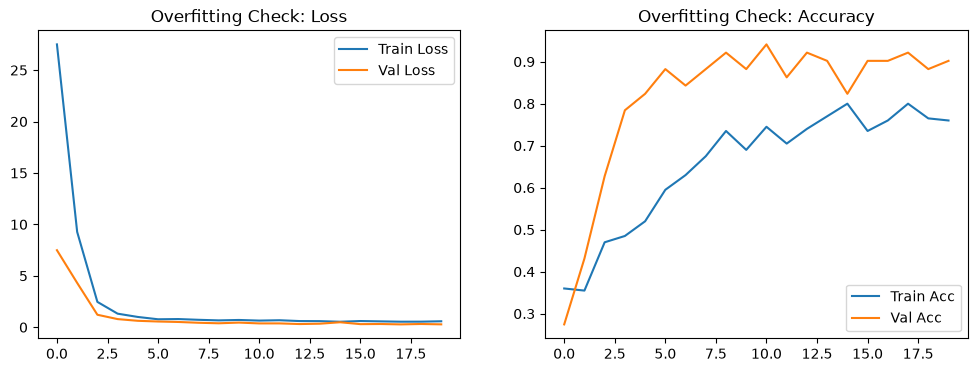

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
ROC-AUC Score (OVR): 0.9450

Classification Report:
                  precision    recall  f1-score   support

          Covid       1.00      0.85      0.92        26
         Normal       0.67      1.00      0.80        20
Viral Pneumonia       0.79      0.55      0.65        20

       accuracy                           0.80        66
      macro avg       0.82      0.80      0.79        66
   weighted avg       0.83      0.80      0.80        66



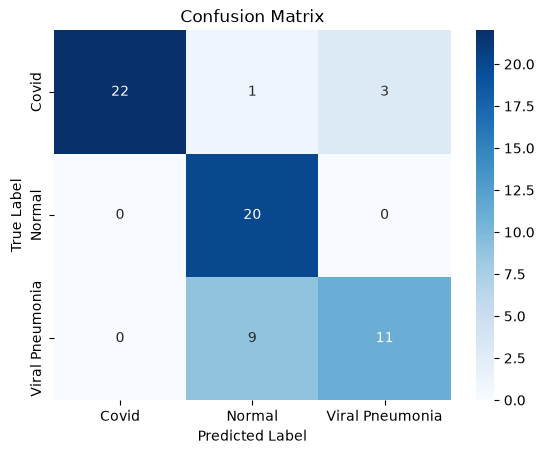

In [7]:
# Creates and trains a basic CNN with Dropout and Data Augmentation to prevent overfitting.
model_1 = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(img_size, img_size, 3)),
    MaxPooling2D(2, 2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3), 
    Dense(3, activation='softmax')
])

model_1.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
early_stop = EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True)

history_1 = model_1.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    validation_data=(X_val, y_val), 
    epochs=20, 
    callbacks=[early_stop], 
    class_weight=class_weights_dict
)
evaluate_model(model_1, history_1, X_test, y_test)

### Model 2: Basic CNN with Dropout and Augmentation

c:\Users\singh\OneDrive\Desktop\cnn_mini_project\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 794ms/step - accuracy: 0.3650 - loss: 2.8772 - val_accuracy: 0.6471 - val_loss: 0.9809
Epoch 2/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 768ms/step - accuracy: 0.5300 - loss: 0.9988 - val_accuracy: 0.6275 - val_loss: 0.8207
Epoch 3/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 833ms/step - accuracy: 0.6700 - loss: 0.7964 - val_accuracy: 0.8431 - val_loss: 0.4613
Epoch 4/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 806ms/step - accuracy: 0.6350 - loss: 0.8194 - val_accuracy: 0.7647 - val_loss: 0.5862
Epoch 5/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 976ms/step - accuracy: 0.6750 - loss: 0.7173 - val_accuracy: 0.8431 - val_loss: 0.4927
Epoch 6/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 727ms/step - accuracy: 0.7600 - loss: 0.5898 - val_accuracy: 0.6863 - val_loss: 0.6717
Epoch 7/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 904ms/step - accuracy: 0.7250 - loss: 0.7506 - val_accuracy: 0.9020 - val_loss: 0.4056
Epoch 8/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 799ms/step - accuracy: 0.7600 - loss: 0.5911 - val_accuracy: 0.9020 - val_loss:

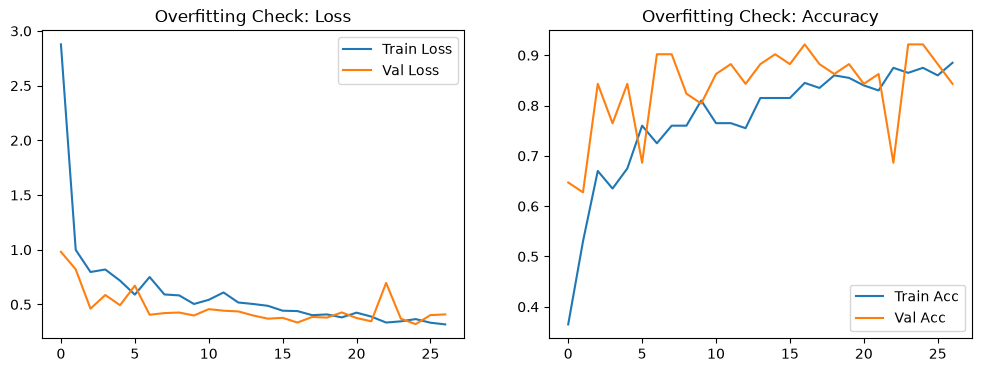

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 122ms/step
ROC-AUC Score (OVR): 0.9469

Classification Report:
                  precision    recall  f1-score   support

          Covid       1.00      0.92      0.96        26
         Normal       0.76      0.95      0.84        20
Viral Pneumonia       0.82      0.70      0.76        20

       accuracy                           0.86        66
      macro avg       0.86      0.86      0.85        66
   weighted avg       0.87      0.86      0.86        66



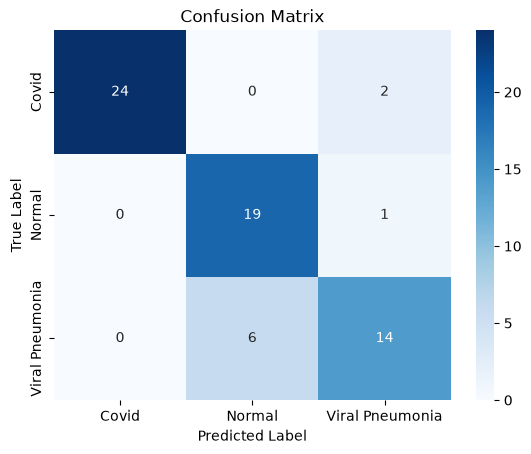

In [8]:
# Deep CNN Architecture: Building a "bigger engine" from scratch
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model_2 = Sequential([
    # Block 1: The Basic "Eyes" (Finds edges and contrast)
    Conv2D(32, (3, 3), activation='relu', input_shape=(img_size, img_size, 3)),
    MaxPooling2D(2, 2),
    
    # Block 2: The Intermediate "Eyes" (Combines edges into shapes/textures)
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    
    # Block 3: The Advanced "Eyes" (Finds complex medical patterns)
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    
    # The Decision Maker
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(3, activation='softmax')
])

model_2.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# We allow up to 30 epochs because a deeper model built from scratch takes longer to learn.
# EarlyStopping will still automatically stop it if it finishes learning early.
history_2 = model_2.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    validation_data=(X_val, y_val), 
    epochs=30, 
    callbacks=[early_stop], 
    class_weight=class_weights_dict
)

evaluate_model(model_2, history_2, X_test, y_test)

### Model 3: Transfer Learning VGG16 with GAP, Dropout, and Reduced Learning Rate

Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 36s 5s/step - accuracy: 0.3700 - loss: 4.6303 - val_accuracy: 0.5098 - val_loss: 4.3163
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 34s 5s/step - accuracy: 0.5850 - loss: 4.2772 - val_accuracy: 0.7255 - val_loss: 3.9837
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 34s 5s/step - accuracy: 0.6950 - loss: 3.9868 - val_accuracy: 0.8039 - val_loss: 3.8320
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 34s 5s/step - accuracy: 0.7300 - loss: 3.8049 - val_accuracy: 0.7843 - val_loss: 3.6075
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 34s 5s/step - accuracy: 0.8150 - loss: 3.6212 - val_accuracy: 0.8431 - val_loss: 3.4764
Epoch 6/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 34s 5s/step - accuracy: 0.8750 - loss: 3.4329 - val_accuracy: 0.9608 - val_loss: 3.2664
Epoch 7/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 36s 5s/step - accuracy: 0.9000 - loss: 3.3183 - val_accuracy: 0.9020 - val_loss: 3.1957
Epoch 8/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 36s 5s/step - accuracy: 0.8500 - loss: 3.3331 - val_accuracy: 0.9412 - val_loss: 3.1196
Epoch 9/

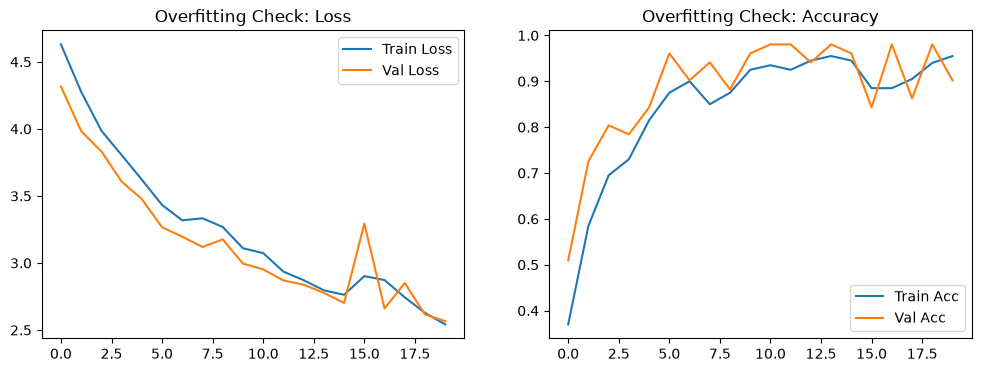

2/3 ━━━━━━━━━━━━━━━━━━━━ 4s 5s/step WARNING:tensorflow:6 out of the last 9 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x000001F24AF800E0> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
3/3 ━━━━━━━━━━━━━━━━━━━━ 10s 3s/step
ROC-AUC Score (OVR): 0.9935

Classification Report:
                  precision    recall  f1-score   support

          Covid       1.00      1.00      1.00        26
         Normal       0.80      1

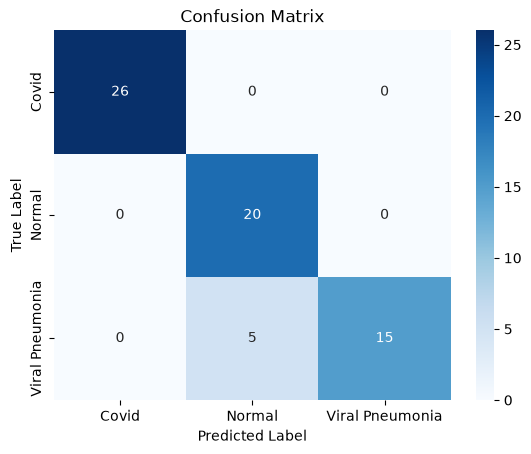

In [9]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

base_model_vgg = VGG16(weights='imagenet', include_top=False, input_shape=(img_size, img_size, 3))

# Unfreeze the last 4 layers again so it can actually learn X-ray textures
for layer in base_model_vgg.layers[:-4]:
    layer.trainable = False

x = GlobalAveragePooling2D()(base_model_vgg.output)

# Added L2 Regularizer to strictly penalize memorization
x = Dense(256, activation='relu', kernel_regularizer=l2(0.01))(x)

x = Dropout(0.5)(x) 
output = Dense(3, activation='softmax')(x)

model_3 = Model(inputs=base_model_vgg.input, outputs=output)

model_3.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

history_3 = model_3.fit(
    datagen.flow(X_train, y_train, batch_size=32), 
    validation_data=(X_val, y_val), 
    epochs=20, 
    callbacks=[early_stop], 
    class_weight=class_weights_dict
)

evaluate_model(model_3, history_3, X_test, y_test)

### Model 4: Transfer Learning + Data Augmentation with ResNet50 Fine-Tuned

Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 24s 3s/step - accuracy: 0.3400 - loss: 1.2359 - val_accuracy: 0.2745 - val_loss: 1.1080
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.3300 - loss: 1.2575 - val_accuracy: 0.4314 - val_loss: 1.0800
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.3550 - loss: 1.2766 - val_accuracy: 0.5294 - val_loss: 1.0672
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step - accuracy: 0.3350 - loss: 1.3092 - val_accuracy: 0.2745 - val_loss: 1.1011
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step - accuracy: 0.2700 - loss: 1.2935 - val_accuracy: 0.2745 - val_loss: 1.1080
Epoch 6/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step - accuracy: 0.3550 - loss: 1.1803 - val_accuracy: 0.2941 - val_loss: 1.0631
Epoch 7/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step - accuracy: 0.3250 - loss: 1.2752 - val_accuracy: 0.5882 - val_loss: 1.0504
Epoch 8/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step - accuracy: 0.3950 - loss: 1.1014 - val_accuracy: 0.6275 - val_loss: 1.0270
Epoch 9/

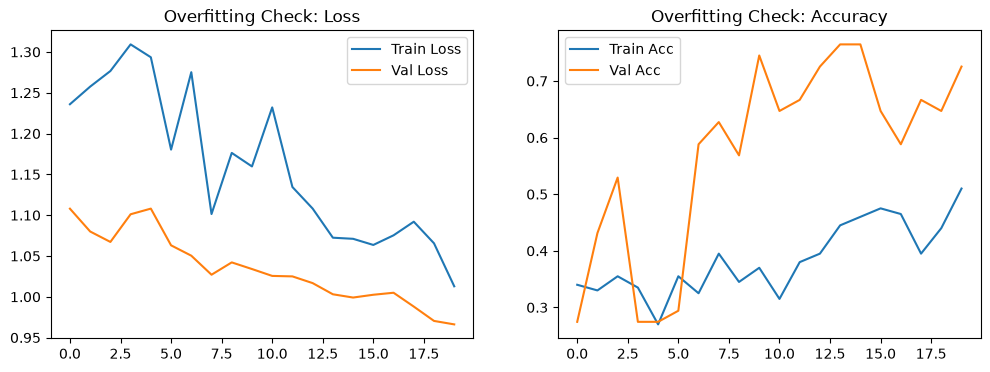

3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step
ROC-AUC Score (OVR): 0.8837

Classification Report:
                  precision    recall  f1-score   support

          Covid       0.96      0.92      0.94        26
         Normal       0.75      0.75      0.75        20
Viral Pneumonia       0.67      0.70      0.68        20

       accuracy                           0.80        66
      macro avg       0.79      0.79      0.79        66
   weighted avg       0.81      0.80      0.80        66



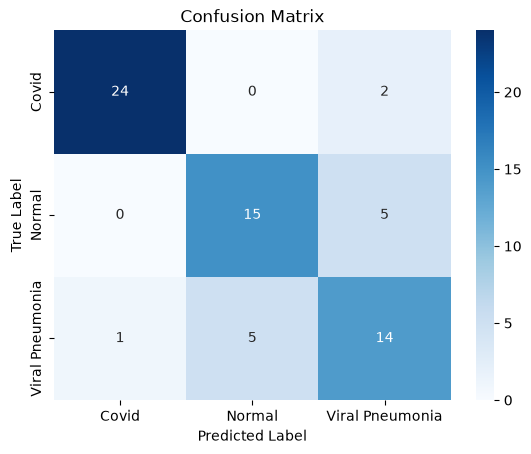

In [10]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout

base_model_resnet = ResNet50(weights='imagenet', include_top=False, input_shape=(img_size, img_size, 3))

for layer in base_model_resnet.layers:
    layer.trainable = False

x = GlobalAveragePooling2D()(base_model_resnet.output)

x = Dense(256, activation='relu')(x)

x = Dropout(0.5)(x) 
output = Dense(3, activation='softmax')(x)

model_4 = Model(inputs=base_model_resnet.input, outputs=output)

model_4.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

history_4 = model_4.fit(
    datagen.flow(X_train, y_train, batch_size=32), 
    validation_data=(X_val, y_val), 
    epochs=20, 
    callbacks=[early_stop], 
    class_weight=class_weights_dict
)

evaluate_model(model_4, history_4, X_test, y_test)

### Model Comparison Table

In [11]:
import pandas as pd
import numpy as np
from sklearn.metrics import f1_score

def get_model_stats(model, history, X_test, y_test):
    train_acc = history.history['accuracy'][-1]
    
    loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
    
    y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
    y_true = np.argmax(y_test, axis=1)
    f1 = f1_score(y_true, y_pred, average='weighted')
    
    val_acc = history.history['val_accuracy'][-1]
    if train_acc - test_acc > 0.05: 
        overfitting = "Y"
    else:
        overfitting = "N"
        
    return round(train_acc, 4), round(test_acc, 4), round(f1, 4), overfitting

m1_train, m1_test, m1_f1, m1_over = get_model_stats(model_1, history_1, X_test, y_test)
m2_train, m2_test, m2_f1, m2_over = get_model_stats(model_2, history_2, X_test, y_test)
m3_train, m3_test, m3_f1, m3_over = get_model_stats(model_3, history_3, X_test, y_test)
m4_train, m4_test, m4_f1, m4_over = get_model_stats(model_4, history_4, X_test, y_test)

data = {
    "Model": ["CNN Basic", "Deep CNN", "VGG16", "ResNet50"],
    "Train Acc": [m1_train, m2_train, m3_train, m4_train],
    "Test Acc": [m1_test, m2_test, m3_test, m4_test],
    "F1 Score": [m1_f1, m2_f1, m3_f1, m4_f1],
    "Overfitting (Y/N)": [m1_over, m2_over, m3_over, m4_over]
}

comparison_table = pd.DataFrame(data)


best_idx = comparison_table['Test Acc'].idxmax()

separator = pd.DataFrame([{
    "Model": "-------------------", 
    "Train Acc": "---", 
    "Test Acc": "---", 
    "F1 Score": "---", 
    "Overfitting (Y/N)": "---"
}])

best_row = pd.DataFrame([{
    "Model": f"🏆 BEST: {comparison_table.loc[best_idx, 'Model']}", 
    "Train Acc": comparison_table.loc[best_idx, 'Train Acc'], 
    "Test Acc": comparison_table.loc[best_idx, 'Test Acc'], 
    "F1 Score": comparison_table.loc[best_idx, 'F1 Score'], 
    "Overfitting (Y/N)": comparison_table.loc[best_idx, 'Overfitting (Y/N)']
}])

final_table = pd.concat([comparison_table, separator, best_row], ignore_index=True)

display(final_table)

,Model,Train Acc,Test Acc,F1 Score,Overfitting (Y/N)
0,CNN Basic,0.76,0.803,0.7996,N
1,Deep CNN,0.885,0.8636,0.8634,N
2,VGG16,0.955,0.9242,0.923,N
3,ResNet50,0.51,0.803,0.805,N
4,-------------------,---,---,---,---
5,🏆 BEST: VGG16,0.955,0.9242,0.923,N


In [12]:
model_3.save("model_VGG.h5")